In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

df = pd.read_csv(r'C:\DATA ANALYSIS AND DATA SCIENCE PROJECTS\Multi Scale Energy Stress Analysis\code\anamoly detection and interpretation\forecasting based anomaly detection\forecasting_feature_set.csv')

df['target'] = df['net_load_mw'].shift(-1)
df = df.dropna().reset_index(drop=True)

drop_cols = [
    'net_load_lag_1h', 'net_load_lag_24h',
    'demand_lag_1h', 'demand_lag_24h',
    'wind_gen_lag_24h'
]

df_lstm = df.drop(columns=drop_cols, errors='ignore')

split_index = int(len(df_lstm) * 0.8)

train_df = df_lstm.iloc[:split_index]
test_df  = df_lstm.iloc[split_index:]

X_train = train_df.drop(columns=['target'])
y_train = train_df['target']

X_test = test_df.drop(columns=['target'])
y_test = test_df['target']

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1,1))

def create_sequences(X, y, seq_length):
    Xs, ys = [], []
    for i in range(seq_length, len(X)):
        Xs.append(X[i-seq_length:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

SEQ_LENGTH = 48  # 12 hours (stronger temporal context)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, SEQ_LENGTH)
X_test_seq, y_test_seq   = create_sequences(X_test_scaled, y_test_scaled, SEQ_LENGTH)

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(SEQ_LENGTH, X_train_seq.shape[2])),
    Dropout(0.3),

    LSTM(64, return_sequences=True),
    Dropout(0.3),

    LSTM(32),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

y_pred_scaled = model.predict(X_test_seq)

y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test_seq)

y_pred = y_pred.flatten()
y_test_actual = y_test_actual.flatten()

c:\Users\Hp\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48, 128)        │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 48, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,801 (565.63 KB)

 Trainable params: 144,801 (565.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
2366/2366 ━━━━━━━━━━━━━━━━━━━━ 110s 45ms/step - loss: 0.0014 - val_loss: 4.2997e-04 - learning_rate: 0.0010
Epoch 2/30
2366/2366 ━━━━━━━━━━━━━━━━━━━━ 137s 58ms/step - loss: 4.0569e-04 - val_loss: 1.8737e-04 - learning_rate: 0.0010
Epoch 3/30
2366/2366 ━━━━━━━━━━━━━━━━━━━━ 110s 46ms/step - loss: 3.0729e-04 - val_loss: 1.8173e-04 - learning_rate: 0.0010
Epoch 4/30
2366/2366 ━━━━━━━━━━━━━━━━━━━━ 111s 47ms/step - loss: 2.3420e-04 - val_loss: 6.9080e-04 - learning_rate: 0.0010
Epoch 5/30
2366/2366 ━━━━━━━━━━━━━━━━━━━━ 124s 52ms/step - loss: 1.9835e-04 - val_loss: 7.8792e-04 - learning_rate: 0.0010
Epoch 6/30
2366/2366 ━━━━━━━━━━━━━━━━━━━━ 118s 50ms/step - loss: 1.4654e-04 - val_loss: 8.4797e-04 - learning_rate: 5.0000e-04
Epoch 7/30
2366/2366 ━━━━━━━━━━━━━━━━━━━━ 126s 53ms/step - loss: 1.4077e-04 - val_loss: 5.3132e-04 - learning_rate: 5.0000e-04
Epoch 8/30
2366/2366 ━━━━━━━━━━━━━━━━━━━━ 149s 63ms/step - loss: 1.3408e-04 - val_loss: 8.3060e-04 - learning_rate: 5.0000e-04
657/657 

In [3]:
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae  = mean_absolute_error(y_test_actual, y_pred)
r2   = r2_score(y_test_actual, y_pred)
epsilon = 1e-6
mape = np.mean(np.abs((y_test_actual - y_pred) / (y_test_actual + epsilon))) * 100

print("LSTM PERFORMANCE")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")

errors = y_test_actual - y_pred
print("\nError Summary:")
print(f"Mean Error      : {np.mean(errors):.4f}")
print(f"Std Error       : {np.std(errors):.4f}")
print(f"Max Error       : {np.max(np.abs(errors)):.4f}")

LSTM PERFORMANCE
RMSE : 976.7759
MAE  : 652.3628
R²   : 0.9754
MAPE : 2.99%

Error Summary:
Mean Error      : 454.1593
Std Error       : 864.7720
Max Error       : 6284.0872


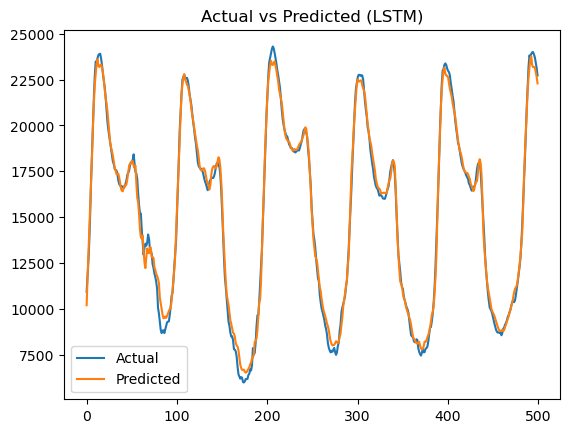

In [4]:
start = 1000
end = 1500

plt.figure()
plt.plot(y_test_actual[start:end], label="Actual")
plt.plot(y_pred[start:end], label="Predicted")
plt.title("Actual vs Predicted (LSTM)")
plt.legend()
plt.show()

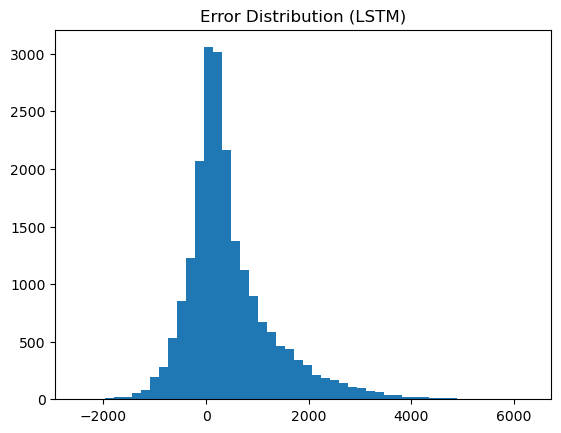

In [5]:
plt.figure()
plt.hist(errors, bins=50)
plt.title("Error Distribution (LSTM)")
plt.show()

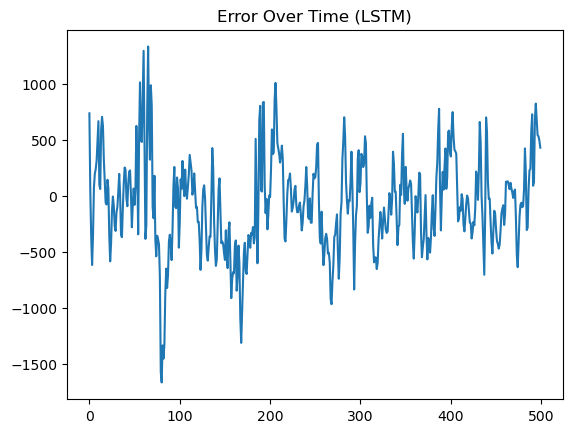

In [6]:
plt.figure()
plt.plot(errors[start:end])
plt.title("Error Over Time (LSTM)")
plt.show()